## Import libraries

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## Download the data

In [2]:
# parameters
ticker = 'SPY'
start_date = '2016-01-01'
end_date = '2026-01-01'

# download the data
print(f'Fetching data for {ticker}')
print(f'Time period {start_date} to {end_date}')

df = yf.download(ticker, start=start_date, end=end_date)
df.head()

Fetching data for SPY
Time period 2016-01-01 to 2026-01-01


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2016-01-04,169.471588,169.480014,167.422950,169.024768,222353500
2016-01-05,169.758163,170.213409,168.653760,169.791880,110845800
2016-01-06,167.616821,168.662205,166.588289,167.212144,152112600
2016-01-07,163.595444,166.453410,163.207631,164.674557,213436100
2016-01-08,161.799698,165.112923,161.513061,164.556501,209817200


## Calculate log return: (ln(price_today/price_yesterday))

We need this feature since log return will normalise the data and keep the math nice. Percentage increases are not symmetrical and log return is a good statistic for describing the volatility of the market.

In [3]:
# we only care about 'Close' price for this model
features = df[['Close']]
features.rename(columns={'Close':'Price'}, inplace=True)
features['log_return'] = np.log(features['Price'] / features['Price'].shift(1))

# drop the first row since it doesn't have a log return value
features = features.iloc[1:]

features.head()

Price,Price,log_return
Ticker,SPY,
Date,,
2016-01-05,169.758163,0.001690
2016-01-06,167.616821,-0.012694
2016-01-07,163.595444,-0.024284
2016-01-08,161.799698,-0.011037
2016-01-11,161.959900,0.000990


## Visualise the log returns

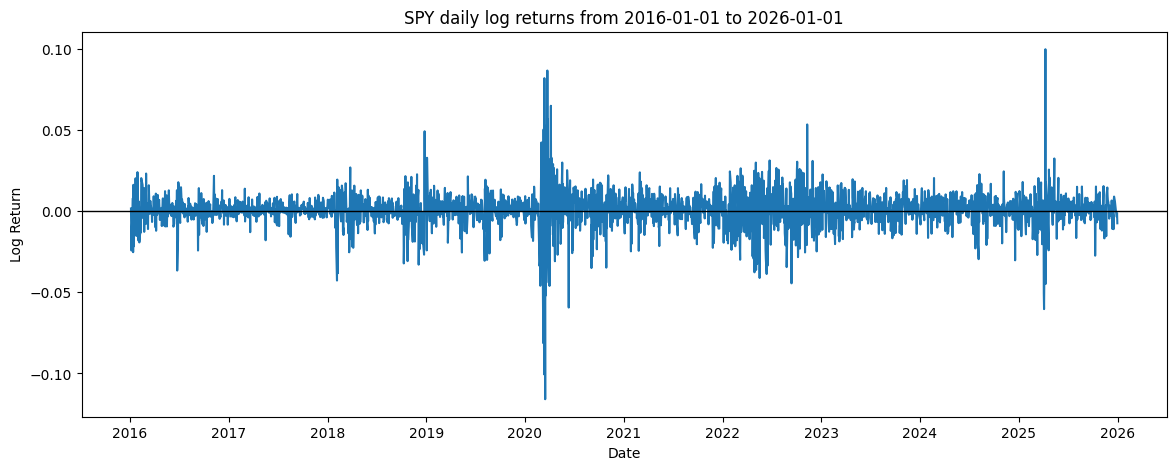

In [4]:
# plot the log returns to spot the high and low volatile regimes
plt.figure(figsize=(14, 5))
plt.plot(features.index, features['log_return'])
plt.title(f'{ticker} daily log returns from {start_date} to {end_date}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.axhline(0, color='black', linewidth=1) # add a horizontal line at y=0
plt.show()

## Calculate rolling average statistics

Calculate rolling average price for the last 20 days to see the trend of the market. Additionally, calculate the rolling average log return to be able to access the volatility of the market.

In [5]:
# calculate rolling average price for last 20 days
features['rolling_avg_price_20'] = features['Price'].rolling(20).mean()

# calculate rolling average log return for last 20 days
features['rolling_avg_return_20'] = features['log_return'].rolling(20).mean()

# drop the nan columns
features.dropna(inplace=True)

features.head(10)

Price,Price,log_return,rolling_avg_price_20,rolling_avg_return_20
Ticker,SPY,,,
Date,,,,
2016-02-02,160.315918,-0.018187,161.193560,-0.002777
2016-02-03,161.277008,0.005977,160.769502,-0.002563
2016-02-04,161.529953,0.001567,160.465159,-0.001849
2016-02-05,158.452774,-0.019234,160.208025,-0.001597
2016-02-08,156.319885,-0.013552,159.934035,-0.001723
2016-02-09,156.328278,0.000054,159.652454,-0.001770
2016-02-10,156.193359,-0.000863,159.298790,-0.002214
2016-02-11,154.161621,-0.013093,159.047134,-0.001606


## Visualise features

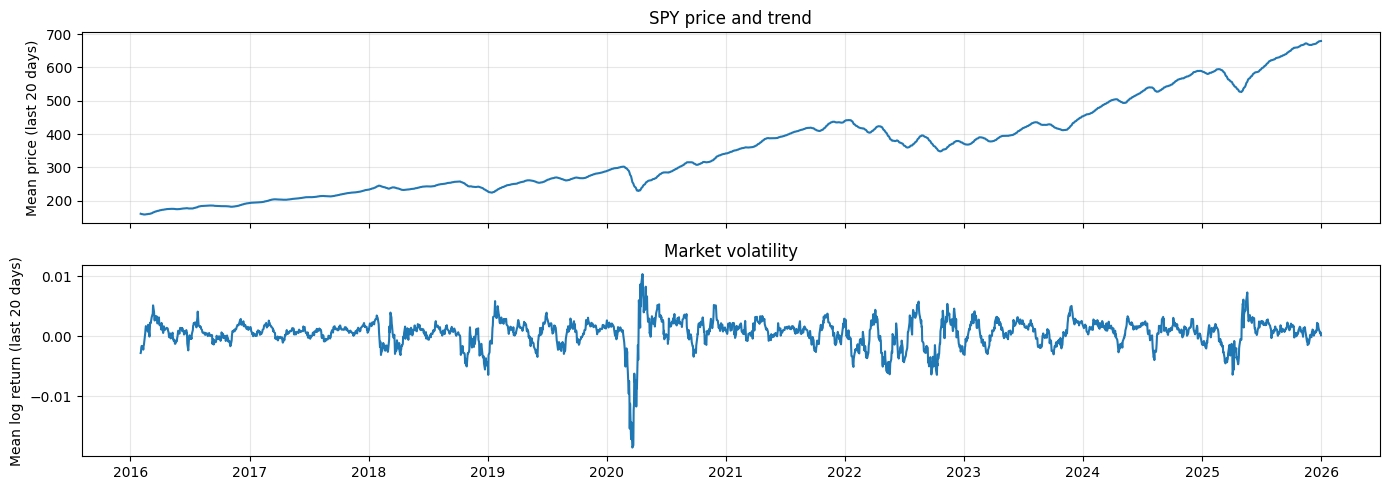

In [6]:
# create a stacked plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

# plot the rolling average price
ax1.plot(features.index, features['rolling_avg_price_20'])
ax1.set_title(f'{ticker} price and trend')
ax1.set_ylabel('Mean price (last 20 days)')
ax1.grid(alpha=0.3)

# plot the rolling average log return
ax2.plot(features.index, features['rolling_avg_return_20'])
ax2.set_title('Market volatility')
ax2.set_ylabel('Mean log return (last 20 days)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# inspect the features
print(features.isnull().sum())
features.describe()

Price                  Ticker
Price                  SPY       0
log_return                       0
rolling_avg_price_20             0
rolling_avg_return_20            0
dtype: int64


Price,Price,log_return,rolling_avg_price_20,rolling_avg_return_20
Ticker,SPY,,,
count,2494.000000,2494.000000,2494.000000,2494.000000
mean,354.164796,0.000571,352.185355,0.000576
std,135.749306,0.011340,134.596976,0.002263
min,154.161621,-0.115886,158.823724,-0.018544
25%,240.380283,-0.003568,240.126706,-0.000305
50%,345.491852,0.000729,346.073524,0.000918
75%,429.410843,0.005923,427.633969,0.001800
max,686.730530,0.099863,679.058319,0.010380


## Machine learning 

Use random forest machine learning

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# create target regimes by splitting the rolling volatility into 3 buckets
low_vol = features['rolling_avg_return_20'].quantile(0.33)
high_vol = features['rolling_avg_return_20'].quantile(0.66)

# 0 = calm market, 1 = medium volatility, 2 = panic market
def assign_regime(x):
    if x <= low_vol:
        return 0
    elif x <= high_vol:
        return 1
    else:
        return 2

features['target_regime'] = features['rolling_avg_return_20'].apply(assign_regime)

# define features and targets
feat = ['rolling_avg_price_20', 'rolling_avg_return_20']
X = features[feat]
y = features['target_regime']

# split the data into training and test data (80% for training)
split_index = int(len(features) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f'{len(X_train)} Training Samples, {len(X_test)} Test Samples')

# train random forest classifier
model = RandomForestClassifier(n_estimators=100, max_depth=5)
model.fit(X_train, y_train)

# evaluate model
y_pred = model.predict(X_test)
print(f'Accuracy of model on test data: {accuracy_score(y_test, y_pred)}')
print(classification_report(y_test, y_pred, target_names=['Low Vol', 'Med Vol', 'High Vol']))

1995 Training Samples, 499 Test Samples
Accuracy of model on test data: 0.9979959919839679
              precision    recall  f1-score   support

     Low Vol       1.00      1.00      1.00       127
     Med Vol       1.00      0.99      1.00       184
    High Vol       0.99      1.00      1.00       188

    accuracy                           1.00       499
   macro avg       1.00      1.00      1.00       499
weighted avg       1.00      1.00      1.00       499



## Visualise the final predictions from the model

<positron-console-cell-30>:29: UserWarning: Legend does not support handles for NoneType instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries


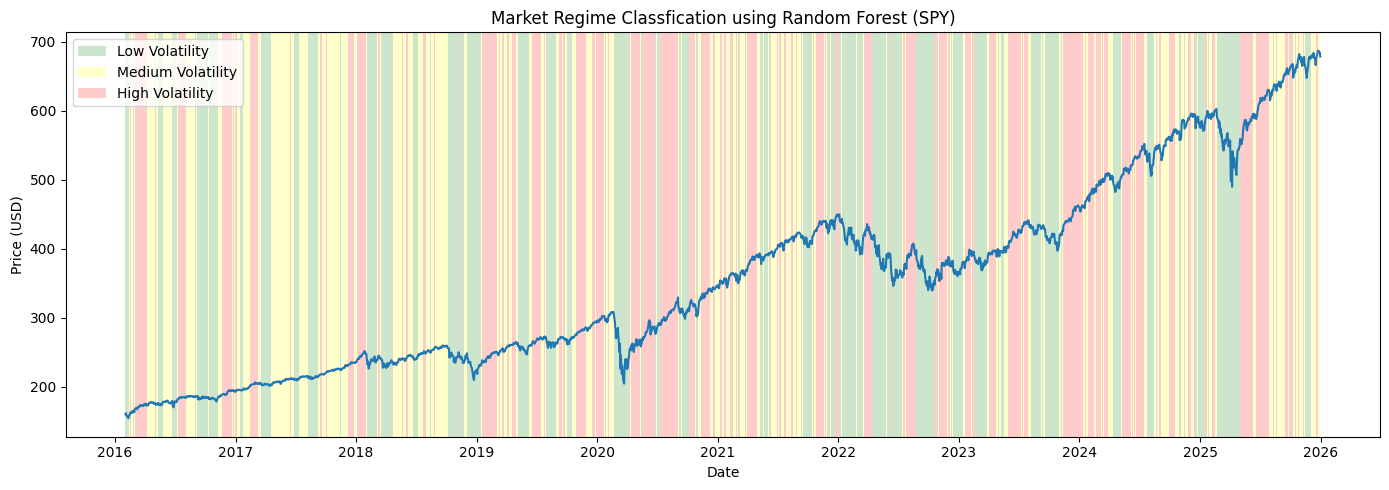

In [30]:
# predict the entire dataset so that it can all be plotted
features['target_regime'] = model.predict(X)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(features.index, features['Price'])

# color-code the background based on regime
colors = {0: 'green', 1: 'yellow', 2: 'red'}
label_added = {0: False, 1: False, 2: False} # to ensure we dont add a label to the legend repeatedly

for i in range(1, len(features)):
    current_regime = features['target_regime'].iloc[i]

    # add a label once per regime
    label = f'Regime {current_regime}' if not label_added[current_regime] else ''
    if not label_added[current_regime]:
        label_added[current_regime] = True

    ax.axvspan(features.index[i-1], features.index[i], color=colors[current_regime], label=label, alpha=0.2, lw=0)

# format graph
ax.set_title(f'Market Regime Classfication using Random Forest ({ticker})')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')

# add a custom legend
handles, labels = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels, handles))
ax.legend([legend_dict.get('SPY Price'), legend_dict.get('Regime 0'), legend_dict.get('Regime 1'), legend_dict.get('Regime 2')],
          ['SPY Price', 'Low Volatility', 'Medium Volatility', 'High Volatility'], 
          loc='upper left')

plt.tight_layout()

# save fig in outputs folder
import os
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/regime_chart.png', dpi=300)

plt.show()